# Modeling Baselines

### Verifying Project Root

In [17]:
import sys

from pathlib import Path

# find project root (one level above notebooks/)
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT / "src"))

print("Project root:", PROJECT_ROOT)

Project root: /Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis


### Imports

In [18]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from modeling.splits import make_random_split, make_time_split, filter_countries_min_years
from modeling.pipelines import build_preprocessor, build_model_pipeline
from modeling.baselines import baseline_mean, linear_regression, ridge_cv, lasso_cv, elasticnet_cv
from modeling.train_eval import train_eval, results_to_dataframe

RANDOM_SEED = 42
TARGET = "life_expectancy"
YEAR_COL = "year"


### Loading Dataset

In [19]:
df = pd.read_csv("../data/processed/main_dataset.csv")
df.head(), df.shape

(       country  year      status  life_expectancy  adult_mortality  \
 0  Afghanistan  2015  Developing             65.0            263.0   
 1  Afghanistan  2014  Developing             59.9            271.0   
 2  Afghanistan  2013  Developing             59.9            268.0   
 3  Afghanistan  2012  Developing             59.5            272.0   
 4  Afghanistan  2011  Developing             59.2            275.0   
 
    infant_deaths  alcohol  percentage_expenditure  hepatitis_b  measles  ...  \
 0             62     0.01               71.279624         65.0      100  ...   
 1             64     0.01               73.523582         62.0      100  ...   
 2             66     0.01               73.219243         64.0      100  ...   
 3             69     0.01               78.184215         67.0      100  ...   
 4             71     0.01                7.097109         68.0      100  ...   
 
    undernourishment          co2  health_expenditure_percent  \
 0              21.

### Basic Assertions

In [20]:
assert TARGET in df.columns
assert "country" in df.columns
assert YEAR_COL in df.columns
# year should be int-ish
df[YEAR_COL] = pd.to_numeric(df[YEAR_COL], errors="raise").astype(int)

## Leakage & ID columns to drop

In [21]:
leakage_cols = ["life_expectancy", "life_expectancy_wb"]
id_cols = ["country_code"]  # keep for diagnostics only, not predictors
# keep region/income_group for error analysis later, but decide if you want them as features
group_cols = ["region", "income_group"]  # for grouping diagnostics

### Building modeling dataframe (dropping target NAs; dropping leakage; choosing predictors)

In [22]:
model_df = df.dropna(subset=[TARGET]).copy()

# predictors start = everything except target
X_df = model_df.drop(columns=[TARGET], errors="ignore").copy()

# remove leakage and identifiers
X_df = X_df.drop(columns=[c for c in leakage_cols if c in X_df.columns], errors="ignore")
X_df = X_df.drop(columns=[c for c in id_cols if c in X_df.columns], errors="ignore")

# decide whether to keep year as a feature:
KEEP_YEAR = True
if not KEEP_YEAR and YEAR_COL in X_df.columns:
    X_df = X_df.drop(columns=[YEAR_COL])

# status encoding 
if "status" in X_df.columns:
    X_df["status_flag"] = (X_df["status"].astype(str).str.lower().str.contains("developed")).astype(int)
    # drop original text status from predictors
    X_df = X_df.drop(columns=["status"])

# Rebuild final modeling df with X + y + ids for later
final_df = X_df.copy()
final_df[TARGET] = model_df[TARGET].values

# Add ids back *only* for later inspection/plots (not as predictors)
for c in ["country", "country_code", "region", "income_group", YEAR_COL]:
    if c in model_df.columns and c not in final_df.columns:
        final_df[c] = model_df[c].values

final_df.shape, final_df.columns[:10]

((2265, 34),
 Index(['country', 'year', 'adult_mortality', 'infant_deaths', 'alcohol',
        'percentage_expenditure', 'hepatitis_b', 'measles', 'bmi',
        'under_five_deaths'],
       dtype='str'))

### Numeric vs Categorical

In [23]:
# numeric predictors only (for a clean first pass)
predictor_cols = [c for c in final_df.columns if c not in [TARGET, "country", "country_code", "region", "income_group"]]

X_only = final_df[predictor_cols].copy()

numeric_cols = X_only.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_only.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_cols, categorical_cols

(['year',
  'adult_mortality',
  'infant_deaths',
  'alcohol',
  'percentage_expenditure',
  'hepatitis_b',
  'measles',
  'bmi',
  'under_five_deaths',
  'polio',
  'total_expenditure',
  'diphtheria',
  'hiv_aids',
  'gdp',
  'population',
  'thinness_1_19_years',
  'thinness_5_9_years',
  'income_composition_of_resources',
  'schooling',
  'undernourishment',
  'co2',
  'health_expenditure_percent',
  'education_expenditure_percent',
  'unemployment',
  'sanitation',
  'injuries',
  'communicable',
  'noncommunicable_disease',
  'status_flag'],
 [])

### Feature Sets (Full vs Reduced)

In [24]:
# Full set (all predictors)
FEATURES_FULL = predictor_cols.copy()

# Reduced set 
drop_candidates = []

# keep under_five_deaths, drop infant_deaths
if "infant_deaths" in FEATURES_FULL and "under_five_deaths" in FEATURES_FULL:
    drop_candidates.append("infant_deaths")

# keep thinness_1_19_years, drop thinness_5_9_years
if "thinness_5_9_years" in FEATURES_FULL and "thinness_1_19_years" in FEATURES_FULL:
    drop_candidates.append("thinness_5_9_years")


FEATURES_REDUCED = [c for c in FEATURES_FULL if c not in drop_candidates]

print("Full:", len(FEATURES_FULL), "Reduced:", len(FEATURES_REDUCED))
drop_candidates

Full: 29 Reduced: 27


['infant_deaths', 'thinness_5_9_years']

### Model Runner Helper

In [ ]:
def run_models_on_split(split_name, X_train, X_test, y_train, y_test, feature_list):
    results = []
    pred_dfs = {}  # keep predictions for diagnostics notebook

    # select columns
    Xtr = X_train[feature_list].copy()
    Xte = X_test[feature_list].copy()

    # define columns again after feature selection
    num_cols = Xtr.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = Xtr.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    pre = build_preprocessor(num_cols, cat_cols, scale_numeric=True)

    models = {
        "MeanBaseline": baseline_mean(),
        "Linear": linear_regression(),
        "RidgeCV": ridge_cv(),
        "LassoCV": lasso_cv(random_state=RANDOM_SEED),
        "ElasticNetCV": elasticnet_cv(random_state=RANDOM_SEED),
    }

    for name, m in models.items():
        pipe = build_model_pipeline(m, pre)
        res, pred_df = train_eval(
            pipe, Xtr, y_train, Xte, y_test,
            model_name=name, split_name=split_name,
            return_predictions_df=True,
            id_df=None, id_cols==["country", "year"] 
        )
        results.append(res)
        pred_dfs[name] = pred_df

    return results, pred_dfs


## Random Split Results (Full vs Reduced)

In [26]:
X_train, X_test, y_train, y_test, info_rand = make_random_split(final_df, target_col=TARGET, test_size=0.2, seed=RANDOM_SEED)

res_full_rand, preds_full_rand = run_models_on_split("random_full", X_train, X_test, y_train, y_test, FEATURES_FULL)
res_red_rand,  preds_red_rand  = run_models_on_split("random_reduced", X_train, X_test, y_train, y_test, FEATURES_REDUCED)

df_results_rand = results_to_dataframe(res_full_rand + res_red_rand).sort_values(["split_name","rmse"])
df_results_rand

,model_name,split_name,n_train,n_test,rmse,mae,r2
2,RidgeCV,random_full,1812,453,3.465644,2.651305,0.879677
1,Linear,random_full,1812,453,3.466003,2.651183,0.879652
4,ElasticNetCV,random_full,1812,453,3.497463,2.691904,0.877457
3,LassoCV,random_full,1812,453,3.606714,2.755333,0.869682
0,MeanBaseline,random_full,1812,453,9.992520,8.156092,-0.000301
7,RidgeCV,random_reduced,1812,453,3.525599,2.718148,0.875478
6,Linear,random_reduced,1812,453,3.526731,2.706458,0.875398
9,ElasticNetCV,random_reduced,1812,453,3.529035,2.726632,0.875235
8,LassoCV,random_reduced,1812,453,3.606709,2.755329,0.869682
5,MeanBaseline,random_reduced,1812,453,9.992520,8.156092,-0.000301


## Time split results (Full vs Reduced)

In [11]:
# balanced panel for time split stability
balanced_df = filter_countries_min_years(final_df, min_years=5)

X_train, X_test, y_train, y_test, info_time = make_time_split(balanced_df, target_col=TARGET, year_col=YEAR_COL, test_years=3)

res_full_time, preds_full_time = run_models_on_split("time_full", X_train, X_test, y_train, y_test, FEATURES_FULL)
res_red_time,  preds_red_time  = run_models_on_split("time_reduced", X_train, X_test, y_train, y_test, FEATURES_REDUCED)

df_results_time = results_to_dataframe(res_full_time + res_red_time).sort_values(["split_name","rmse"])
df_results_time

,model_name,split_name,n_train,n_test,rmse,mae,r2
3,LassoCV,time_full,1812,453,3.136893,2.494059,0.859587
4,ElasticNetCV,time_full,1812,453,3.153890,2.516712,0.858062
2,RidgeCV,time_full,1812,453,3.154436,2.523547,0.858013
1,Linear,time_full,1812,453,3.216877,2.553161,0.852336
0,MeanBaseline,time_full,1812,453,8.777449,7.563970,-0.099368
8,LassoCV,time_reduced,1812,453,3.136964,2.494132,0.859581
7,RidgeCV,time_reduced,1812,453,3.154714,2.523854,0.857988
9,ElasticNetCV,time_reduced,1812,453,3.159605,2.522113,0.857547
6,Linear,time_reduced,1812,453,3.231647,2.585503,0.850977
5,MeanBaseline,time_reduced,1812,453,8.777449,7.563970,-0.099368


## One Combined Table

In [12]:
all_results = pd.concat([df_results_rand, df_results_time], ignore_index=True)
all_results = all_results.sort_values(["split_name","rmse"])
all_results

,model_name,split_name,n_train,n_test,rmse,mae,r2
0,RidgeCV,random_full,1812,453,3.465644,2.651305,0.879677
1,Linear,random_full,1812,453,3.466003,2.651183,0.879652
2,ElasticNetCV,random_full,1812,453,3.497463,2.691904,0.877457
3,LassoCV,random_full,1812,453,3.606714,2.755333,0.869682
4,MeanBaseline,random_full,1812,453,9.992520,8.156092,-0.000301
5,RidgeCV,random_reduced,1812,453,3.525599,2.718148,0.875478
6,Linear,random_reduced,1812,453,3.526731,2.706458,0.875398
7,ElasticNetCV,random_reduced,1812,453,3.529035,2.726632,0.875235
8,LassoCV,random_reduced,1812,453,3.606709,2.755329,0.869682
9,MeanBaseline,random_reduced,1812,453,9.992520,8.156092,-0.000301


### Saving Artifacts

In [25]:
import os
os.makedirs("../outputs/metrics", exist_ok=True)

all_results.to_csv("../outputs/metrics/week4_baseline_results.csv", index=False)

with open("../outputs/metrics/final_features_full.json", "w") as f:
    json.dump(FEATURES_FULL, f, indent=2)

with open("../outputs/metrics/final_features_reduced.json", "w") as f:
    json.dump(FEATURES_REDUCED, f, indent=2)

print("Saved ../outputs/metrics/week4_baseline_results.csv and feature lists.")

Saved ../outputs/metrics/week4_baseline_results.csv and feature lists.


## Barplot for Time Aware Split

/var/folders/z1/h4t_14t16kx2dlrnwd603z8c0000gn/T/ipykernel_43997/593154939.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/z1/h4t_14t16kx2dlrnwd603z8c0000gn/T/ipykernel_43997/593154939.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/z1/h4t_14t16kx2dlrnwd603z8c0000gn/T/ipykernel_43997/593154939.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


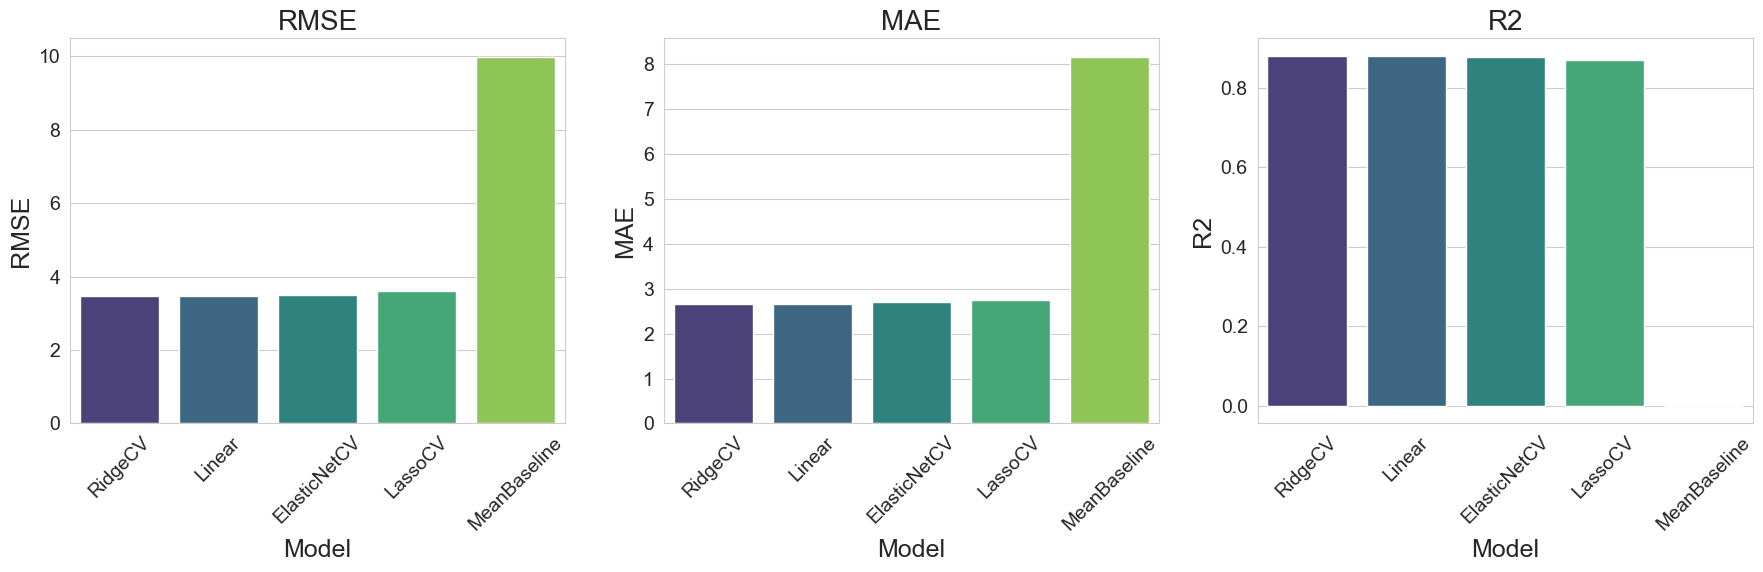

In [13]:
df = pd.read_csv("../outputs/metrics/week4_baseline_results.csv")

df_plot = df[df["split_name"] == "random_full"]

sns.set_style("whitegrid")

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

metrics = ["rmse", "mae", "r2"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_plot,
        x="model_name",
        y=metric,
        ax=axes[i],
        palette="viridis"
    )

    axes[i].set_title(metric.upper())
    axes[i].set_xlabel("Model")
    axes[i].set_ylabel(metric.upper())
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()